# K-means clustering

In this section you will create clusters based on book ratings using K-means operations. 

Are there similarities between books when we plot them in a graph? Are there possible clusters we can derive from this spatial layout? 

To help us cluster our book data, we will be using the sklearn Kmeans and a graph layout function from Ch.7 in our manual. 

## 1. Load the dataset

Load the subset book ratings you created in the previous notebook.

In [2]:
import pandas as pd
df_books_ratings = pd.read_csv('data/BX-Book-Ratings-Subset.csv', sep=';')
df_books_ratings

,User-ID,ISBN,Book-Rating
0,276762,0380711524,5
1,276762,0451167317,0
2,276847,0446364193,0
3,276847,3426029553,8
4,276925,002542730X,10
...,...,...,...
259054,276688,0688143687,0
259055,276688,0688156134,8
259056,276688,0836218655,10
259057,276688,0836236688,10


## 2. Construct a ratings matrix 

To cluster our data, we need to construct a matrix with all the ratings. Each row of the matrix represents the ratings for a book, and each column represents a user. For each cell in the matrix, the value is the rating given by that user for that book.

Can you construct such a (huge!) matrix with the dataset? (Hint: use the pandas dataframe `pivot` function)

In [4]:
ratings_matrix = df_books_ratings.pivot(index='ISBN', columns='User-ID', values='Book-Rating').fillna(0)
ratings_matrix

User-ID,242,243,254,383,388,408,446,487,503,507,...,278202,278221,278356,278418,278535,278563,278582,278633,278843,278851
ISBN,,,,,,,,,,,,,,,,,,,,,
000649840X,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006547834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006550681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0006550789,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0007110928,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3896672282,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8408043641,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8433925180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3.  Construct a sparse matrix using scipy.sparse

Most of the cells in the matrix are empty; these are the cases where a user did not rate a particular book.

To work with the data more efficiently, we need to transform into a *sparse matrix* format. This is a data structure designed for sparse data (like our matrix). It only stores the cells that actually have a value.

Convert your matrix to a `scipy.sparse` `csr_matrix`.

Tip: `csr_matrix` will count "0" values as empty. If your matrix uses "NaN" values for empty cells, you will need to replace those with 0 first.

In [5]:
from scipy.sparse import csr_matrix

sparse_matrix = csr_matrix(ratings_matrix.values)

sparse_matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 83634 stored elements and shape (5490, 7016)>

## 3. Cluster!

Now that you have your matrix ready it is time to cluster! 

Can you fit your matrix into the 3x clusters Kmeans object?  

In [6]:
from sklearn.cluster import KMeans

kmeans_3_clusters = KMeans(n_clusters=3)

clusters = kmeans_3_clusters.fit(sparse_matrix)


What does the  `clusters ` variable hold in terms of data?

In [7]:
clusters

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [14]:
# The clusters object contains the hyperparameters used during training (number of
# clusters, algorithm used, number of input features, etc.)
# It also contains the trained parameters that are be used classify input
# (clusters.cluster_centers_). This specifies how much each user's ratings are associated
# with each cluster.
# Also, clusters.labels_ specifies the cluster assigned to each book after training.

## 5. Visualise clusters

Below is a (modified) `plot` function from our book discussed in Ch.7. section 7.4.2, which displays clusters in a graph.

It does the following:
- It simplifies the data into 2 dimensions
- It creates clusters based on the simplified data
- It shows a plot with the simplified data and the clusters.

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot(user_ratings: csr_matrix, k: int):

        h = 0.2
        reduced_data = PCA(n_components=2).fit_transform(user_ratings)

        kmeans = KMeans(init='k-means++', n_clusters=k, n_init=10)
        kmeans.fit(reduced_data)

        x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
        y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
        xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

        Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

        # Put the result into a color plot
        Z = Z.reshape(xx.shape)

        plt.figure(1)
        plt.clf()
        plt.imshow(Z, interpolation='nearest',
                   extent=(xx.min(), xx.max(), yy.min(), yy.max()),
                   cmap=plt.cm.Paired,
                   aspect='auto', origin='lower')

        centroids = kmeans.cluster_centers_
        plt.plot(reduced_data[:, 0], reduced_data[:, 1], 'k.', markersize=2)
        plt.scatter(centroids[:, 0], centroids[:, 1],
                    marker='x', s=169, linewidths=3,
                    color='r', zorder=10)
        plt.title('K-means clustering of books')

Let's use this function to see how our books data can be clustered.  

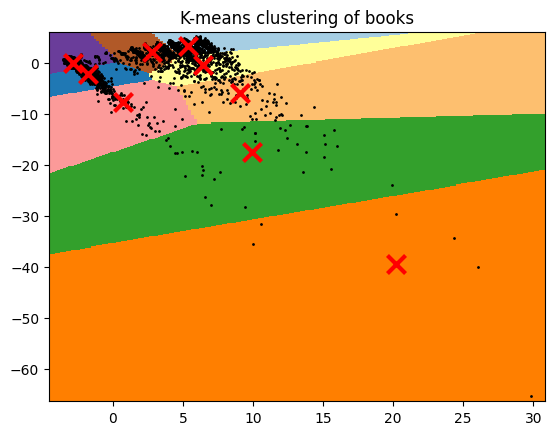

In [22]:
plot(user_ratings=sparse_matrix, k=9)

## 6. How about users?

Can we you use the code above to cluster *users* depending on their ratings?

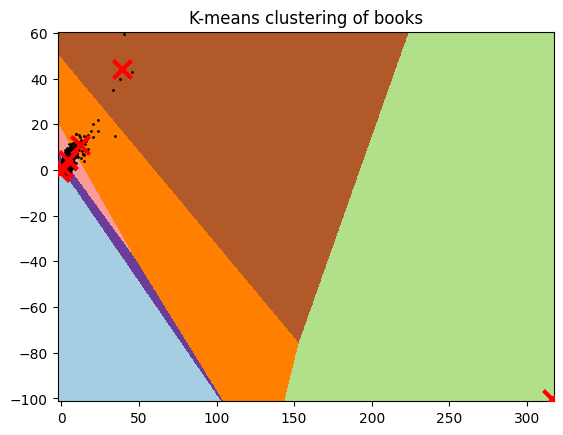

In [23]:
df_users = df_books_ratings.pivot(index='User-ID', columns='ISBN', values='Book-Rating').fillna(0)
df_users

matrix_user = csr_matrix(df_users.values)

plot(user_ratings=matrix_user, k=6)

## 7. Saving clusters

Use the model you created in step 6 to create a dataframe that assigns each user to a cluster. It should have one column for user IDs, and one column for cluster labels. Export the dataframe to the data directory.

Tip: on a trained clustering model, you can use `.transform(data)` to get clusters for the input values in `data`.

In [24]:
# saving clusters

kmeans_6_clusters = KMeans(n_clusters=6)

clusters_users = kmeans_6_clusters.fit(matrix_user)

# print(clusters_users.labels_)

df_to_save = pd.DataFrame()
df_to_save['User-ID'] = df_users.index
df_to_save['Cluster'] = clusters_users.labels_

df_to_save.to_csv('data/BX-users-cluster-6.csv', index=False, sep=';')